# Dataset preparation

In [1]:
# open file and read lines
file=open(r"C:\Users\D506\Desktop\Project TRR\Dataset\pr144.tsp", "r")
lines=file.readlines()
# remove first 6 lines and last line (because these lines do not contain node coordinates)
lines=lines[6:-1]
l=[]
for line in lines:
    if len(line.split())==3:
        node,x,y=line.split()
        l.append([int(node),float(x),float(y)])
print(l)

[[1, 4350.0, 4425.0], [2, 4500.0, 4425.0], [3, 4300.0, 4725.0], [4, 4300.0, 4825.0], [5, 4300.0, 4950.0], [6, 4300.0, 5050.0], [7, 4350.0, 8875.0], [8, 4500.0, 8875.0], [9, 4300.0, 9175.0], [10, 4300.0, 9275.0], [11, 4300.0, 9400.0], [12, 4300.0, 9500.0], [13, 4950.0, 10600.0], [14, 5150.0, 10600.0], [15, 5525.0, 9525.0], [16, 5525.0, 9425.0], [17, 5525.0, 9225.0], [18, 5525.0, 9125.0], [19, 4950.0, 8875.0], [20, 5250.0, 8875.0], [21, 5550.0, 8875.0], [22, 4950.0, 6150.0], [23, 5150.0, 6150.0], [24, 5525.0, 5075.0], [25, 5525.0, 4975.0], [26, 5525.0, 4775.0], [27, 5525.0, 4675.0], [28, 4950.0, 4425.0], [29, 5250.0, 4425.0], [30, 5550.0, 4425.0], [31, 5875.0, 2325.0], [32, 5875.0, 2475.0], [33, 5875.0, 2625.0], [34, 5875.0, 2775.0], [35, 5675.0, 4825.0], [36, 5675.0, 4925.0], [37, 5875.0, 6775.0], [38, 5875.0, 6925.0], [39, 5875.0, 7075.0], [40, 5875.0, 7225.0], [41, 5675.0, 9275.0], [42, 5675.0, 9375.0], [43, 8125.0, 10150.0], [44, 8225.0, 10150.0], [45, 8325.0, 10150.0], [46, 8125.0, 

In [2]:
# creating a distance matrix
import math
# calculate the distance between two nodes using the Euclidean distance formula
def distance(u,v):
    return ((u[1]-v[1])**2+(u[2]-v[2])**2)**0.5
# create a size n x n matrix to store the distances between all pairs of nodes
def matrix_dis(l):
    n=len(l)
    dis=[[0]*n for _ in range(n)]
    # calculate the distance between each pair of nodes and store it in the matrix
    for i in range(n):
        for j in range(i+1,n):
            dis[i][j]=dis[j][i]=distance(l[i],l[j])
    return dis
D=matrix_dis(l)

In [3]:
# calculating the length of a tour
def tour_length(tour,D):
    length=0
    for i in range(len(tour)):
        length+=D[tour[i]][tour[(i+1)%len(tour)]]
    return length

# Execution Time

In [4]:
import time
def execution_time_ms(start_counter):
    return (time.perf_counter() - start_counter) * 1000

# Greedy algorithms

In [5]:
# finding the best position to insert a node into a tour
def best_insertion(tour,k,D):
    best_delta=math.inf
    pos=0
    for i in range(len(tour)):
        delta=D[tour[i]][k]+D[k][tour[(i+1)%len(tour)]]-D[tour[i]][tour[(i+1)%len(tour)]]
        if delta<best_delta:
            best_delta=delta
            pos=i+1
    return pos,best_delta

# finding the nearest pair of nodes to start the tour (use in the cheapest insertion algorithm and nearest insertion algorithm)
def nearest_pair_seed(D):
    n=len(D)
    length=math.inf
    for i in range(n):
        for j in range(i+1,n):
            if D[i][j]<length:
                length=D[i][j]
                best_i=i
                best_j=j
    return [best_i,best_j]

# cheapest insertion algorithm
def cheapest_insertion(D):
    #starting with the nearest pair of nodes as the initial tour
    tour=nearest_pair_seed(D)
    n=len(D)
    # create a list of unvisited nodes and remove the nodes in the initial tour from it
    unvisited=list(range(n))
    unvisited.remove(tour[0])
    unvisited.remove(tour[1])
    while len(unvisited)>0:
        best_node=None
        best_delta=math.inf
        best_pos=None
        # for each unvisited node, find the best position to insert it into the tour and calculate the increase in tour length 
        for i in unvisited:
            pos,delta=best_insertion(tour,i,D)
            if delta<best_delta:
                best_delta=delta
                best_node=i
                best_pos=pos
        tour.insert(best_pos,best_node)
        # remove the inserted node from the list of unvisited nodes
        unvisited.remove(best_node)
    return tour

In [6]:
# finding the distance from a city to a tour by finding the minimum distance from the city to any node in the tour
def distance_from_city_to_tour(city,tour,D):
    length=math.inf
    for i in tour:
        if D[city][i]<length:
            length=D[city][i]
    return length

# finding the closest city to a tour by finding the city with the minimum distance from the tour
def find_closest_city_to_tour(remaining,tour,D):
    length=math.inf
    nearest=None
    for i in remaining:
        d=distance_from_city_to_tour(i,tour,D)
        if d<length:
            length=d
            nearest=i
    return nearest

# nearest insertion algorithm
def nearest_insertion_tsp(D):
    n = len(D)
    if n <= 2:
        return list(range(n))
    # starting with the nearest pair of nodes as the initial tour
    tour = nearest_pair_seed(D)
    # create a set of remaining nodes and remove the nodes in the initial tour from it
    remaining = set(range(n)) - set(tour)
    while len(remaining) > 0:
        # insert the closest city to the tour at the position that minimizes the increase in tour length
        best_node = find_closest_city_to_tour(remaining,tour,D)
        pos, delta = best_insertion(tour,best_node,D)
        tour.insert(pos, best_node)
        # remove the inserted node from the set of remaining nodes
        remaining.remove(best_node)
    return tour

In [7]:
# finding the farthest city to a tour by finding the city with the maximum distance from the tour
def find_farthest_city_to_tour(remaining,tour,D):
    length=0
    farthest=None
    for i in remaining:
        d=distance_from_city_to_tour(i,tour,D)
        if d>length:
            length=d
            farthest=i
    return farthest

# farthest insertion algorithm
def farthest_insertion_tsp(D):
    n = len(D)
    if n <= 2:
        return list(range(n))
    # starting with the nearest pair of nodes as the initial tour
    tour = nearest_pair_seed(D)
    # create a set of remaining nodes and remove the nodes in the initial tour from it
    remaining = set(range(n)) - set(tour)
    while len(remaining) > 0:
        # insert the farthest city to the tour at the position that minimizes the increase in tour length
        best_node = find_farthest_city_to_tour(remaining,tour,D)
        pos, delta = best_insertion(tour,best_node,D)
        tour.insert(pos, best_node)
        # remove the inserted node from the set of remaining nodes
        remaining.remove(best_node)
    return tour

# Local search Algorithm

## 2-opt

In [8]:
def reverse_segment(tour,i,j):
    new_tour=tour[:]
    # reverse the segment between indices i and j (inclusive) in the tour
    new_tour[i:j+1]=tour[i:j+1][::-1]
    return new_tour

### First Improvement

In [9]:
def first_improvement_two_opt(tour,D):
    current_tour = tour[:]
    current_cost = tour_length(current_tour , D)
    n = len(current_tour)
    improved = True
    while improved:
        improved = False
        # for each pair of edges in the tour, reverse the segment between them and calculate the cost of the new tour
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                candidate = reverse_segment(current_tour, i, j)
                candidate_cost = tour_length(candidate , D)
                # if the candidate tour is better than the current tour, update the current tour and cost and break out of the inner loop to start over
                if candidate_cost < current_cost:
                    current_tour = candidate
                    current_cost = candidate_cost
                    improved = True
                    break
        # if no improvement was found in the inner loop, break out of the outer loop to finish
        if not improved:
            break
    return current_tour

### Best Improvement

In [10]:
def best_improvement_two_opt(tour, D):
    current_tour = tour[:]
    current_cost = tour_length(current_tour , D)
    n = len(current_tour)
    improved = True
    while improved:
        improved = False
        best_candidate = current_tour
        best_cost = current_cost
        # for each pair of edges in the tour, reverse the segment between them and calculate the cost of the new tour
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                candidate = reverse_segment(current_tour , i, j)
                candidate_cost = tour_length(candidate , D)
                # if the candidate tour is better than the current tour, update the best candidate and best cost
                if candidate_cost < best_cost:
                    best_candidate = candidate
                    best_cost = candidate_cost
                    improved = True
        if improved:
            current_tour = best_candidate
            current_cost = best_cost
    return current_tour

## Local Beam Search

In [11]:
import random
import heapq

def local_beam_search(path, total_dist,beam_width, dist=D):
    n = len(path)
    # create the initial beam as a list of copies of the input path and a list of their corresponding distances
    current_beam = [path.copy() for _ in range(beam_width)]
    current_dist = [0.0] * beam_width
    current_dist[0] = total_dist
    # create random variations of the initial path for the other beams in the beam search
    for b in range(1, beam_width):
        beam_path = current_beam[b]
        for _ in range(b):
            if n > 3:
                i = random.randint(1, n - 2)
                j = random.randint(i + 1, n - 1)
                # reverse the segment between indices i and j (inclusive) in the beam path to create a new variation of the path
                beam_path[i:j+1] = reversed(beam_path[i:j+1])
        # calculating the distance of the new beam path by summing the distances between consecutive nodes in the path
        d = 0.0
        for i in range(n):
            d += dist[beam_path[i]][beam_path[(i + 1) % n]]
        current_dist[b] = d
    # creating an empty list
    while True:
        candidates = []
        candidates_append = candidates.append
        for b in range(beam_width):
            beam_path = current_beam[b]
            beam_dist = current_dist[b]
            # using 2-opt for edge (a,b) and (c,d)
            for i in range(1, n - 1):
                a, b_node = beam_path[i - 1], beam_path[i]
                for j in range(i + 1, n):
                    c = beam_path[j]
                    d = beam_path[0] if j == n - 1 else beam_path[j + 1]
                    # calculating the new tour length 
                    new_dist = beam_dist - dist[a][b_node] - dist[c][d] + dist[a][c] + dist[b_node][d]
                    candidates_append((new_dist, b, i, j))
        # if number of candidates exceed 3k, filtering out the 3k most efficient candidates by using library heapq           
        if len(candidates) > beam_width * 3:
            candidates = heapq.nsmallest(beam_width * 3, candidates, key=lambda x: x[0])
        # if number of candidates under 3k, sorting candidates like usual
        else:
            candidates.sort(key=lambda x: x[0])
        # creating container for the next generation of local beam
        next_beam = [[] for _ in range(beam_width)]
        next_dist = [0.0] * beam_width
        next_count = 0
        best_current_dist = min(current_dist)
        improved = False
        # preventing duplicate journeys
        seen_distances = set()
        # iterating through sorted candidates to choose top k elite candidates
        for cand in candidates:
            if next_count == beam_width:
                break
            cand_dist, parent_beam, swap_i, swap_j = cand
            # use rounded precision to filter structurally identical cost paths
            dist_key = round(cand_dist, 4)
            if dist_key in seen_distances:
                continue
            seen_distances.add(dist_key)
            # using 2-opt algorithm for the selected pair of indices
            next_beam[next_count] = current_beam[parent_beam].copy()
            dst = next_beam[next_count]
            dst[swap_i:swap_j+1] = reversed(dst[swap_i:swap_j+1])
            next_dist[next_count] = cand_dist
            # track if any elite candidate breaks the current generational minimum threshold
            if cand_dist < best_current_dist - 1e-5:
                improved = True
            next_count += 1
        # search if there are any improvements 
        if not improved or next_count == 0:
            break
        # synchronize and truncate active beams for the next iteration loop
        current_beam = next_beam[:next_count]
        current_dist = next_dist[:next_count]
        beam_width = next_count
    # extract the absolute best performing tour from the final generational pool
    best_b = current_dist.index(min(current_dist))
    path[:] = current_beam[best_b]
    return current_beam[best_b]

### Tuning Beam Width

In [12]:
def investigate_beam_width(tour_init, distance_matrix, max_width=30):
    # Investigating tour length and execution time with different beam width value from 1 to 30
    beam_widths = list(range(1, max_width + 1))
    results_dist = []
    results_time = []
    for width in beam_widths:
        test_tour = tour_init.copy()
        init_dist = tour_length(test_tour, distance_matrix)
        t_start = time.perf_counter()
        # Suppose that local beam width now has parameter beam width equals width
        final_dist = local_beam_search_dynamic(test_tour, init_dist, distance_matrix, beam_width=width)
        # execution time
        exec_time_ms = (time.perf_counter() - t_start) * 1000
        results_dist.append(final_dist)
        results_time.append(exec_time_ms)
    return beam_widths, results_dist, results_time

# Fucntion testing execution time and tour length within different beam width
def local_beam_search_dynamic(path, total_dist, dist, beam_width):
    n = len(path)
    # Initialize the parallel population matrix
    current_beam = [path.copy() for _ in range(beam_width)]
    current_dist = [0.0] * beam_width
    current_dist[0] = total_dist
    # randomise 2-opt mutations to enforce population diversity
    for b in range(1, beam_width):
        beam_path = current_beam[b]
        for _ in range(b):
            if n > 3:
                i = random.randint(1, n - 2)
                j = random.randint(i + 1, n - 1)
                beam_path[i:j+1] = reversed(beam_path[i:j+1])
        d = 0.0
        for i in range(n):
            d += dist[beam_path[i]][beam_path[(i + 1) % n]]
        current_dist[b] = d
    while True:
        candidates = []
        candidates_append = candidates.append
        # Generate all valid 2-opt moves across all k beams
        for b in range(beam_width):
            beam_path = current_beam[b]
            beam_dist = current_dist[b]
            for i in range(1, n - 1):
                a, b_node = beam_path[i - 1], beam_path[i]
                for j in range(i + 1, n):
                    c = beam_path[j]
                    d = beam_path[0] if j == n - 1 else beam_path[j + 1]
                    new_dist = beam_dist - dist[a][b_node] - dist[c][d] + dist[a][c] + dist[b_node][d]
                    candidates_append((new_dist, b, i, j))
        # sorting out the top 3k beams if number of candidate exceed 3k            
        if len(candidates) > beam_width * 3:
            candidates = heapq.nsmallest(beam_width * 3, candidates, key=lambda x: x[0])
        else:
            candidates.sort(key=lambda x: x[0])
        # initialize the matrix for the next generation
        next_beam = [[] for _ in range(beam_width)]
        next_dist = [0.0] * beam_width
        next_count = 0
        best_current_dist = min(current_dist)
        improved = False
        seen_distances = set()
        # Filter out structural identical paths to secure diversity
        for cand in candidates:
            if next_count == beam_width:
                break
            cand_dist, parent_beam, swap_i, swap_j = cand
            dist_key = round(cand_dist, 4)
            # reject duplicates
            if dist_key in seen_distances:
                continue
            seen_distances.add(dist_key)
            # execute 2-opt on selected pair of indices
            next_beam[next_count] = current_beam[parent_beam].copy()
            dst = next_beam[next_count]
            dst[swap_i:swap_j+1] = reversed(dst[swap_i:swap_j+1])
            next_dist[next_count] = cand_dist
            # Verify if structural variation breaks the global generational attractor threshold
            if cand_dist < best_current_dist - 1e-5:
                improved = True
            next_count += 1
        # break if no improvements are making or only making duplicates
        if not improved or next_count == 0:
            break
        current_beam = next_beam[:next_count]
        current_dist = next_dist[:next_count]
        beam_width = next_count
    # Extract the best candidate in the last generation pool
    best_b = current_dist.index(min(current_dist))
    path[:] = current_beam[best_b]
    return current_dist[best_b]

# Visualise Path

In [13]:
import matplotlib.pyplot as plt

def plot_local_search_comparison_with_metrics(coords, tour_base, tour_first, tour_best, tour_beam, metrics_dict, algo_name="CIH"):
    # extract unique undirected edges from a permutation array
    def extract_edges(tour_path):
        edges = set()
        for i in range(len(tour_path)):
            u = int(tour_path[i])
            v = int(tour_path[(i + 1) % len(tour_path)])
            # since index in TSPB start from 1 instead of 0, we need to adjust the index to match the coordinates list
            if u > len(coords) or v > len(coords):
                u, v = u - 1, v - 1
            elif u == len(coords) or v == len(coords):
                u, v = u % len(coords), v % len(coords)
            # store edges as sorted tuples to ensure undirected uniqueness
            edges.add((min(u, v), max(u, v)))
        return edges
    # Extract foundational edge matrices from the baseline solution
    edges_base = extract_edges(tour_base)
    # Initialize a 2x2 grid subplot
    fig, axs = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle(f'Comparative Topological & Performance Analysis: Baseline {algo_name}', 
                 fontsize=15, fontweight='bold')
    # Structured configuration mapping each algorithm variant to its respective subplot axis
    plots_config = [
        {
            'tour': tour_base, 'ax': axs[0, 0], 'm_key': 'base',
            'title': f'A) Baseline: {algo_name}'
        },
        {
            'tour': tour_first, 'ax': axs[0, 1], 'm_key': 'first',
            'title': f'B) {algo_name} + 2-opt (First Improvement)'
        },
        {
            'tour': tour_best, 'ax': axs[1, 0], 'm_key': 'best',
            'title': f'C) {algo_name} + 2-opt (Best Improvement)'
        },
        {
            'tour': tour_beam, 'ax': axs[1, 1], 'm_key': 'beam',
            'title': f'D) {algo_name} + Local Beam Search'
        }
    ]
    # Iterate through each algorithm configuration to construct visual subplots
    for idx, cfg in enumerate(plots_config):
        ax = cfg['ax']
        current_tour = cfg['tour']
        m_key = cfg['m_key']
        # Take performance indicators from the metrics dictionary
        length_val = metrics_dict[m_key]['dist']
        time_val = metrics_dict[m_key]['time']
        # Initialise the multi-line title with dynamic performance metrics
        full_title = f"{cfg['title']}\nLength: {length_val:.2f}\nTime: {time_val:.2f} ms"
        ax.set_title(full_title, fontsize=11, fontweight='bold', pad=10)
        # Set nodes as red points
        x_coords, y_coords = [], []
        for node in current_tour:
            n_idx = int(node)
            if n_idx >= len(coords):
                n_idx = n_idx - 1 if n_idx == len(coords) else n_idx % len(coords)
            x_coords.append(coords[n_idx][0])
            y_coords.append(coords[n_idx][1])
        ax.scatter(x_coords, y_coords, color='#d62728', s=25, zorder=3, alpha=0.9, label='Vertices')
        # For the baseline tour, plot all edges in solid blue. For subsequent tours, plot new edges in solid blue and discarded edges in dashed gray.
        if idx == 0:
            for u, v in edges_base:
                ax.plot([coords[u][0], coords[v][0]], [coords[u][1], coords[v][1]], 
                        color='#1f77b4', linestyle='-', linewidth=1.6, zorder=2)
            ax.plot([], [], color='#1f77b4', linestyle='-', label='Current Tour')
        else:
            edges_current = extract_edges(current_tour)
            discarded_edges = edges_base.difference(edges_current)
            for u, v in discarded_edges:
                ax.plot([coords[u][0], coords[v][0]], [coords[u][1], coords[v][1]], 
                        color='#b0b0b0', linestyle='--', linewidth=1.2, alpha=0.7, zorder=1)
            # Plot the current tour edges in solid blue on top of the discarded edges to ensure visibility
            for u, v in edges_current:
                ax.plot([coords[u][0], coords[v][0]], [coords[u][1], coords[v][1]], 
                        color='#1f77b4', linestyle='-', linewidth=1.6, zorder=2)    
            ax.plot([], [], color='#1f77b4', linestyle='-', label='Current Tour')
            ax.plot([], [], color='#b0b0b0', linestyle='--', label='Discarded Paths')
        # Finalize subplot aesthetics
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.set_xlabel('Spatial X Coordinate', fontsize=10)
        ax.set_ylabel('Spatial Y Coordinate', fontsize=10)
        ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

# Cheapest Insertion

In [14]:
# cheapest insertion 
t_start=time.perf_counter()
tour_cheap=cheapest_insertion(D)
time_cheap=execution_time_ms(t_start)

# cheapest + 2-opt first improvement
t_start=time.perf_counter()
tour_cheap_2opt_first=first_improvement_two_opt(tour_cheap.copy(),D)
time_cheap_2opt_first=execution_time_ms(t_start)

# cheapest + 2-opt best improvement
t_start=time.perf_counter()
tour_cheap_2opt_best=best_improvement_two_opt(tour_cheap.copy(),D)
time_cheap_2opt_best=execution_time_ms(t_start)

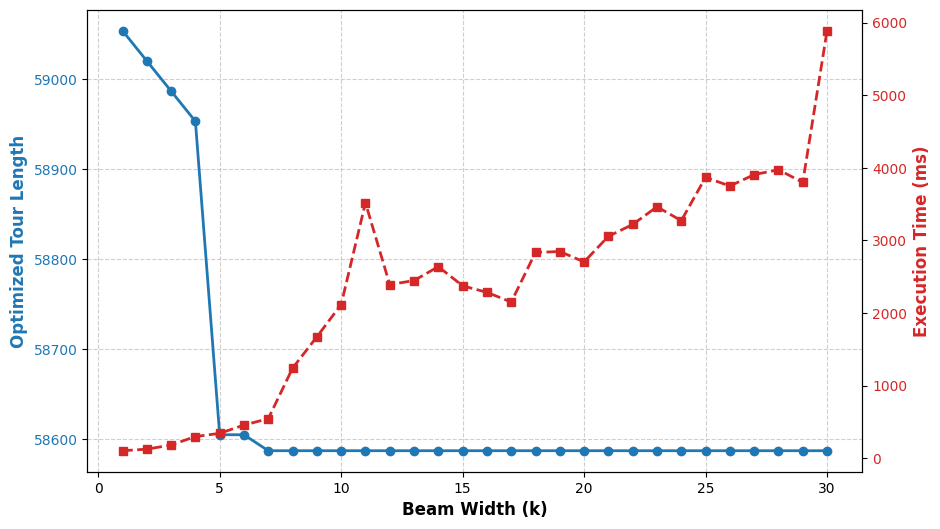

In [15]:
import matplotlib.pyplot as plt
# visualise tuning beam width
widths, distances, times = investigate_beam_width(tour_cheap.copy(), D, max_width=30)

# Visualising the time execution and tour length with different beam width
fig, ax1 = plt.subplots(figsize=(10, 6))

# The blue line represent the tour length
color = 'tab:blue'
ax1.set_xlabel('Beam Width (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Optimized Tour Length', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(widths, distances, color=color, marker='o', linewidth=2, label='Tour Length')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# Red line represent execution time
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Execution Time (ms)', color=color, fontsize=12, fontweight='bold')
line2 = ax2.plot(widths, times, color=color, marker='s', linestyle='--', linewidth=2, label='Runtime (ms)')
ax2.tick_params(axis='y', labelcolor=color)

In [16]:
# cheapest + local beam search
t_start=time.perf_counter()
tour_cheap_beam_search=local_beam_search(tour_cheap.copy(),tour_length(tour_cheap,D),7)
time_cheap_beam_search=execution_time_ms(t_start)

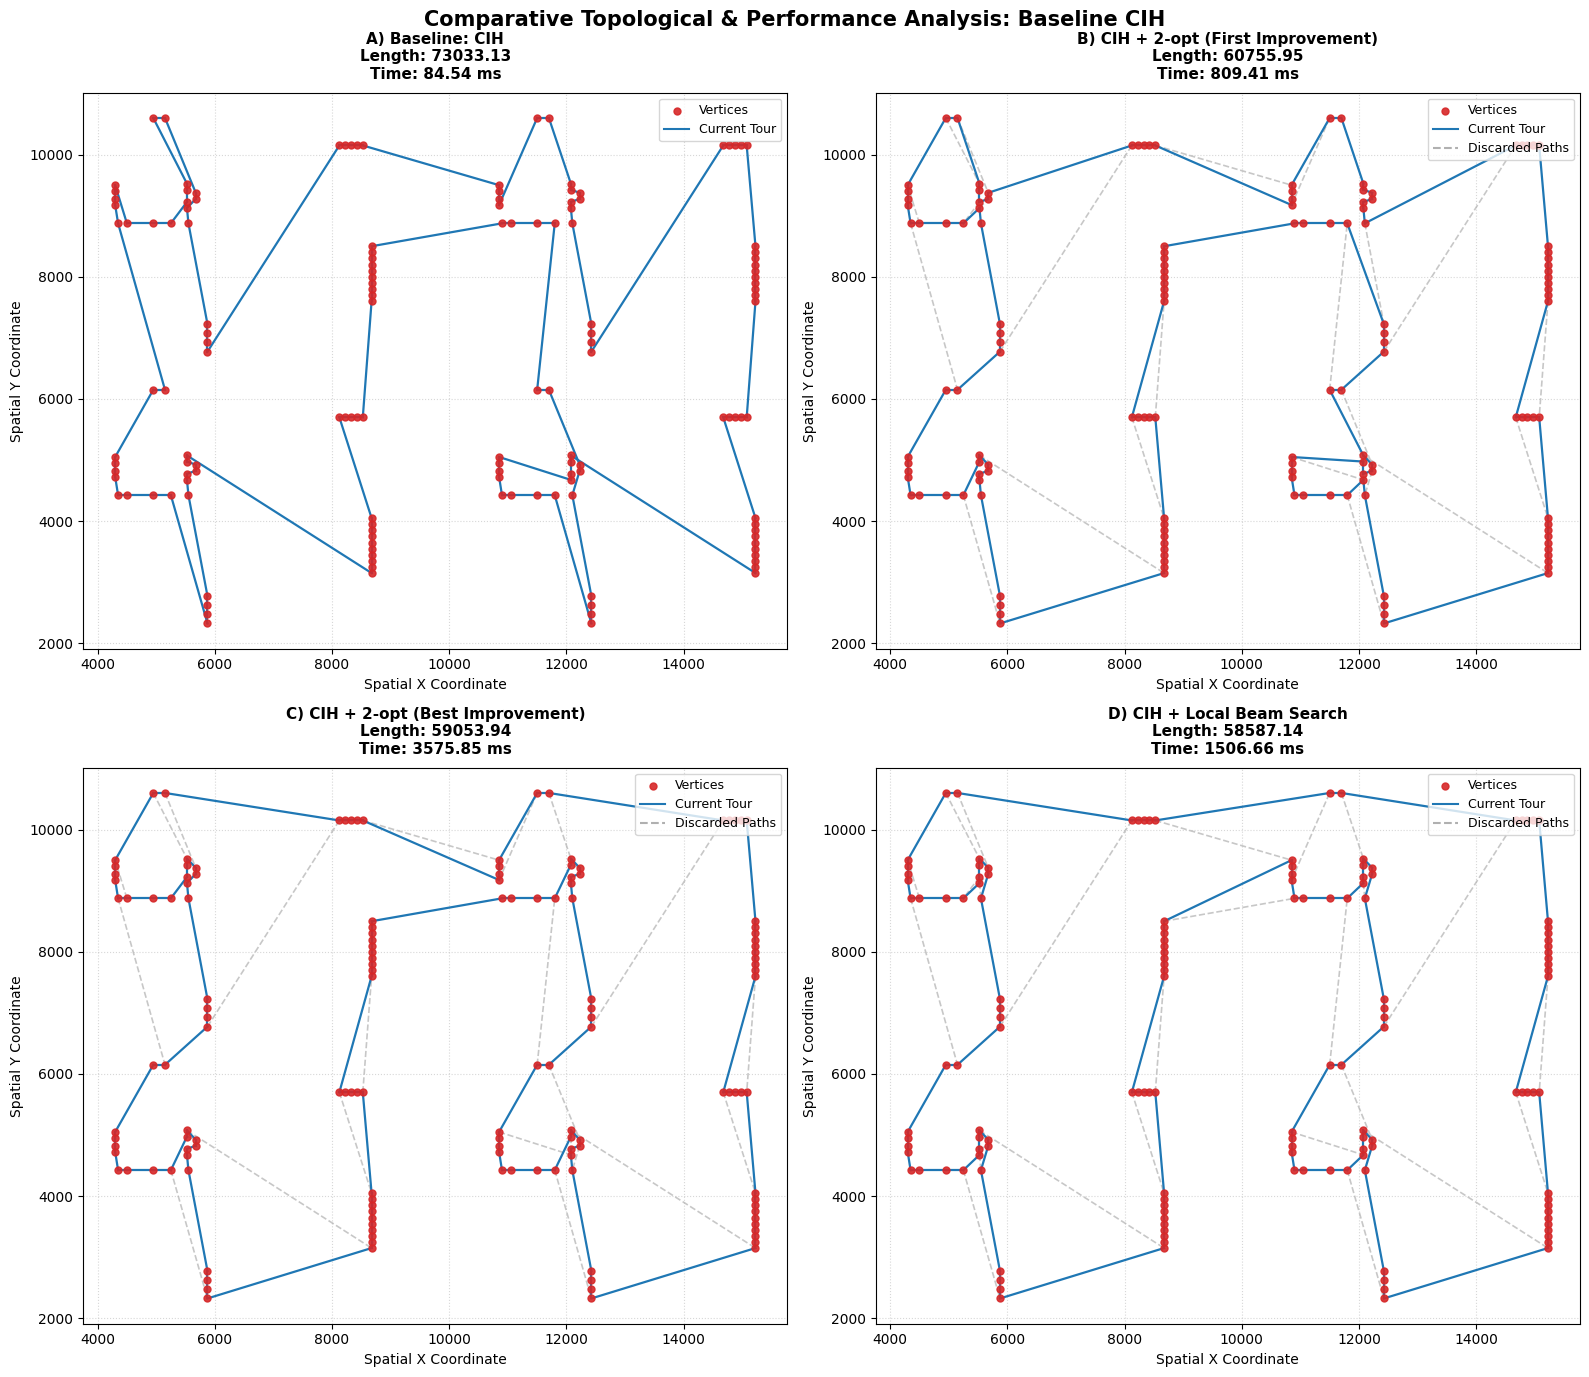

In [17]:
# Compile performance metrics into a structured dictionary for visualization
perf_data = {
    'base':  {'dist': tour_length(tour_cheap, D),       'time': time_cheap},
    'first': {'dist': tour_length(tour_cheap_2opt_first, D), 'time': time_cheap_2opt_first},
    'best':  {'dist': tour_length(tour_cheap_2opt_best, D),  'time': time_cheap_2opt_best},
    'beam':  {'dist': tour_length(tour_cheap_beam_search, D),'time': time_cheap_beam_search}
}

# Extracting coordinates from the original data list for plotting
coords = [(item[1], item[2]) for item in l]

plot_local_search_comparison_with_metrics(
    coords, 
    tour_cheap, 
    tour_cheap_2opt_first, 
    tour_cheap_2opt_best, 
    tour_cheap_beam_search,
    metrics_dict=perf_data,   
    algo_name="CIH"   )      

# Nearest Insertion

In [18]:
# nearest insertion 
t_start=time.perf_counter()
tour_near=nearest_insertion_tsp(D)
time_near=execution_time_ms(t_start)

# nearest + 2-opt first improvement
t_start=time.perf_counter()
tour_near_2opt_first=first_improvement_two_opt(tour_near.copy(),D)
time_near_2opt_first=execution_time_ms(t_start)

# nearest + 2-opt best improvement
t_start=time.perf_counter()
tour_near_2opt_best=best_improvement_two_opt(tour_near.copy(),D)
time_near_2opt_best=execution_time_ms(t_start)

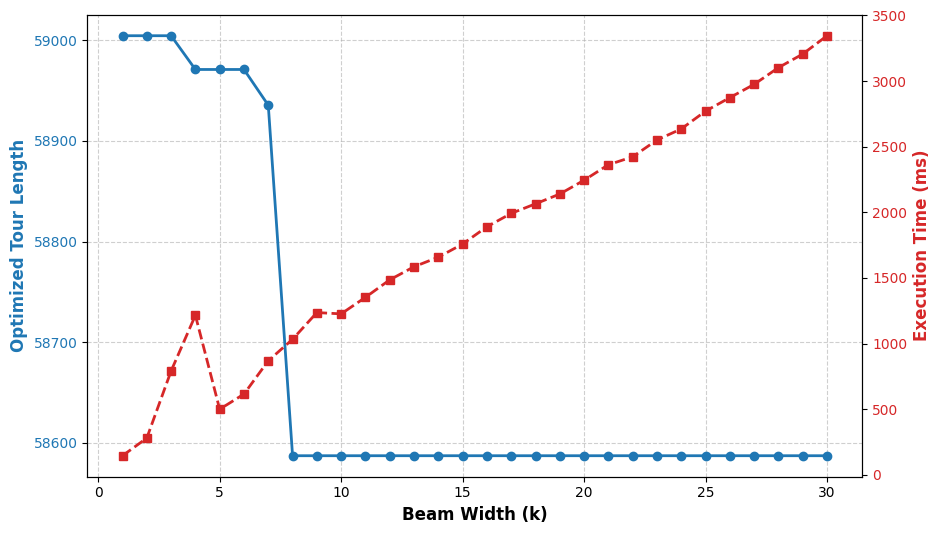

In [19]:
# visualise tuning beam width
widths, distances, times = investigate_beam_width(tour_near.copy(), D, max_width=30)

# Visualising the time execution and tour length with different beam width
fig, ax1 = plt.subplots(figsize=(10, 6))

# The blue line represent the tour length
color = 'tab:blue'
ax1.set_xlabel('Beam Width (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Optimized Tour Length', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(widths, distances, color=color, marker='o', linewidth=2, label='Tour Length')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# Red line represent execution time
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Execution Time (ms)', color=color, fontsize=12, fontweight='bold')
line2 = ax2.plot(widths, times, color=color, marker='s', linestyle='--', linewidth=2, label='Runtime (ms)')
ax2.tick_params(axis='y', labelcolor=color)

In [20]:
#nearest insertion + local beam search
t_start=time.perf_counter()
tour_near_beam_search=local_beam_search(tour_near.copy(),tour_length(tour_near,D),8)
time_near_beam_search=execution_time_ms(t_start)

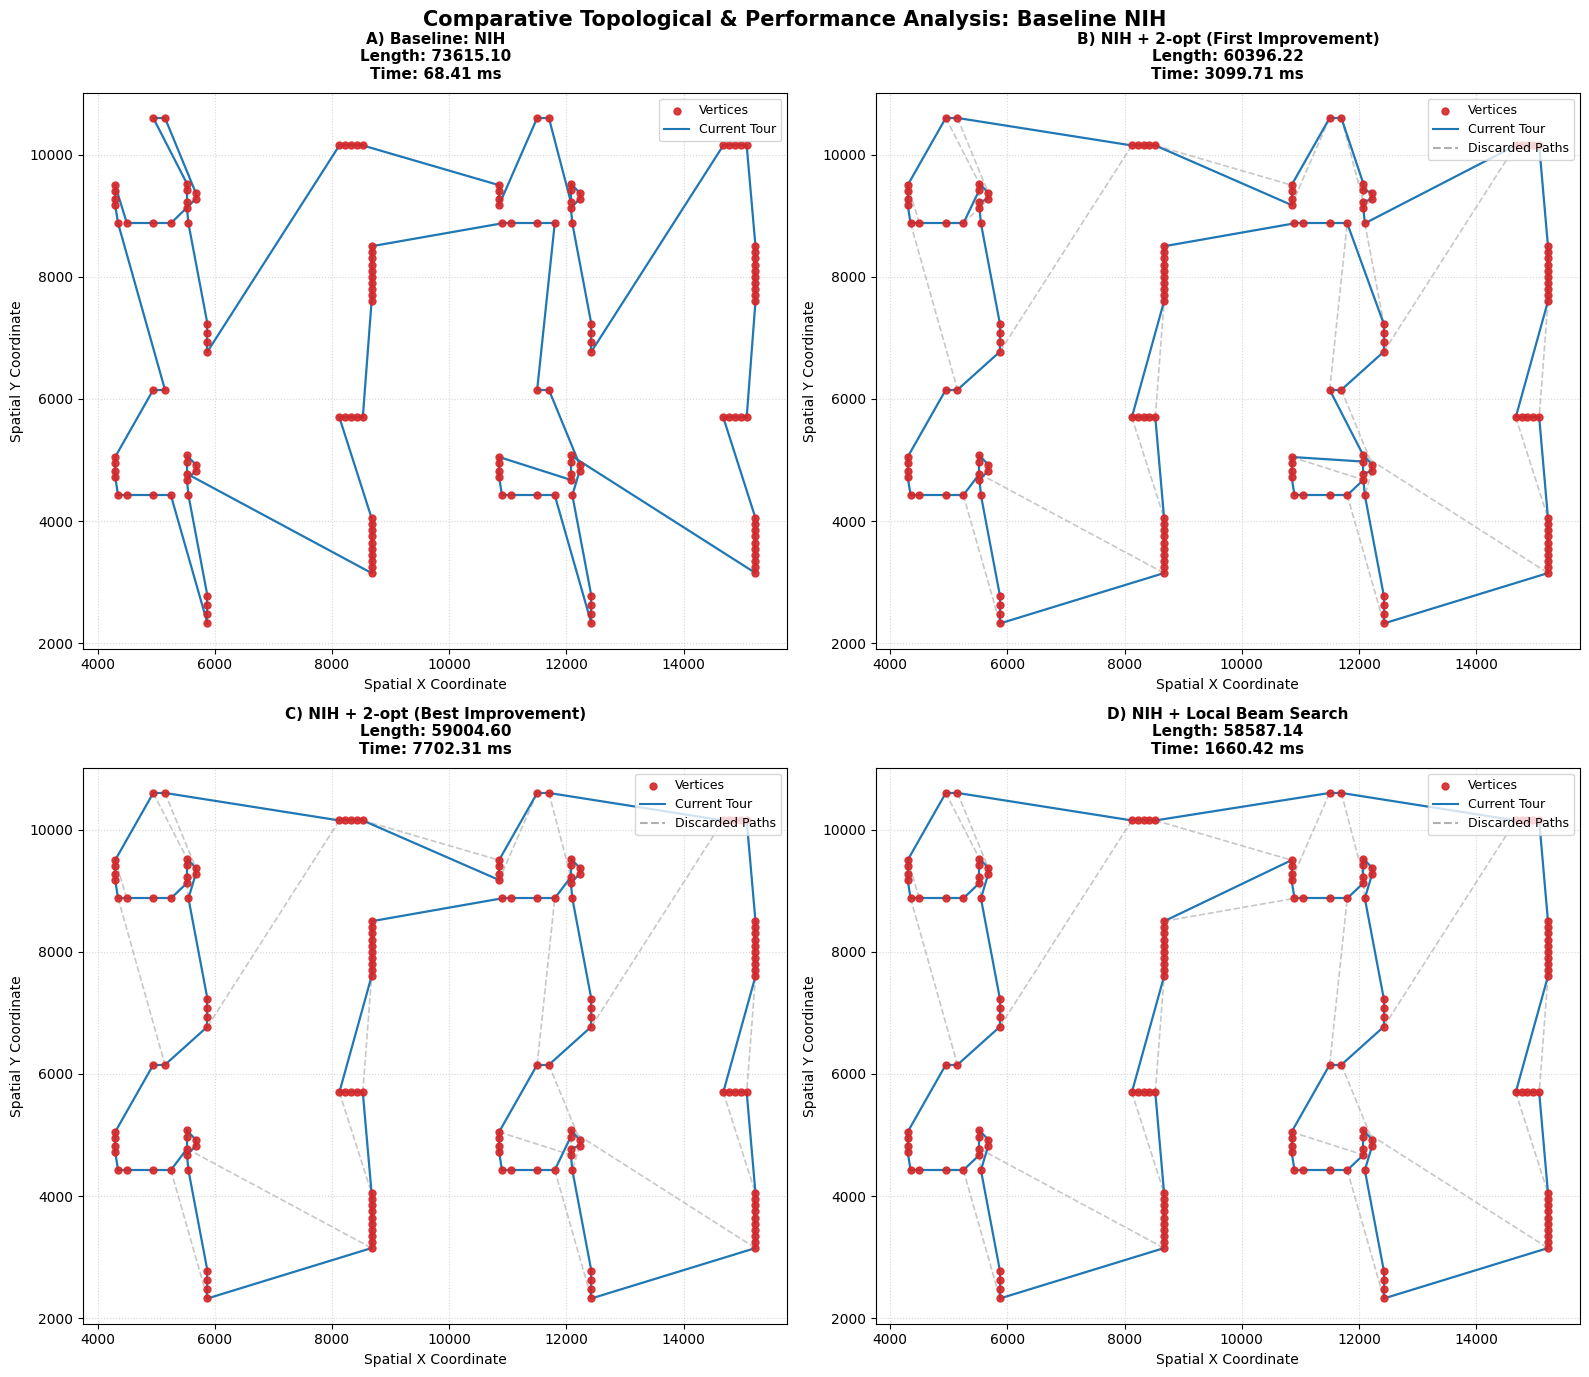

In [21]:
# Compile performance metrics into a structured dictionary for visualization
perf_data = {
    'base':  {'dist': tour_length(tour_near, D),       'time': time_near},
    'first': {'dist': tour_length(tour_near_2opt_first, D), 'time': time_near_2opt_first},
    'best':  {'dist': tour_length(tour_near_2opt_best, D),  'time': time_near_2opt_best},
    'beam':  {'dist': tour_length(tour_near_beam_search, D),'time': time_near_beam_search}
}

# Extracting coordinates from the original data list for plotting
coords = [(item[1], item[2]) for item in l]

plot_local_search_comparison_with_metrics(
    coords, 
    tour_near, 
    tour_near_2opt_first, 
    tour_near_2opt_best, 
    tour_near_beam_search,
    metrics_dict=perf_data,   
    algo_name="NIH"          
)

# Farthest Insertion

In [22]:
# farthest insertion
t_start=time.perf_counter()
tour_far=farthest_insertion_tsp(D)
time_far=execution_time_ms(t_start)

# farthest + 2-opt first improvement
t_start=time.perf_counter()
tour_far_2opt_first=first_improvement_two_opt(tour_far.copy(),D)
time_far_2opt_first=execution_time_ms(t_start)

# farthest + 2-opt best improvement
t_start=time.perf_counter()
tour_far_2opt_best=best_improvement_two_opt(tour_far.copy(),D)
time_far_2opt_best=execution_time_ms(t_start)

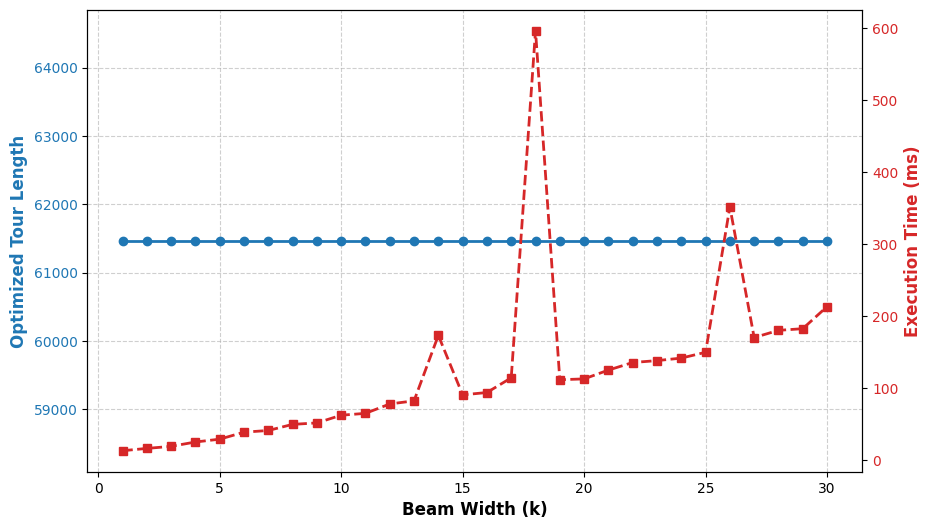

In [23]:
# visualise tuning beam width
widths, distances, times = investigate_beam_width(tour_far.copy(), D, max_width=30)

# Visualising the time execution and tour length with different beam width
fig, ax1 = plt.subplots(figsize=(10, 6))

# The blue line represent the tour length
color = 'tab:blue'
ax1.set_xlabel('Beam Width (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Optimized Tour Length', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(widths, distances, color=color, marker='o', linewidth=2, label='Tour Length')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# Red line represent execution time
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Execution Time (ms)', color=color, fontsize=12, fontweight='bold')
line2 = ax2.plot(widths, times, color=color, marker='s', linestyle='--', linewidth=2, label='Runtime (ms)')
ax2.tick_params(axis='y', labelcolor=color)

In [24]:
#farthest insertion + local beam search
t_start=time.perf_counter()
tour_far_beam_search=local_beam_search(tour_far.copy(),tour_length(tour_near,D),3)
time_far_beam_search=execution_time_ms(t_start)

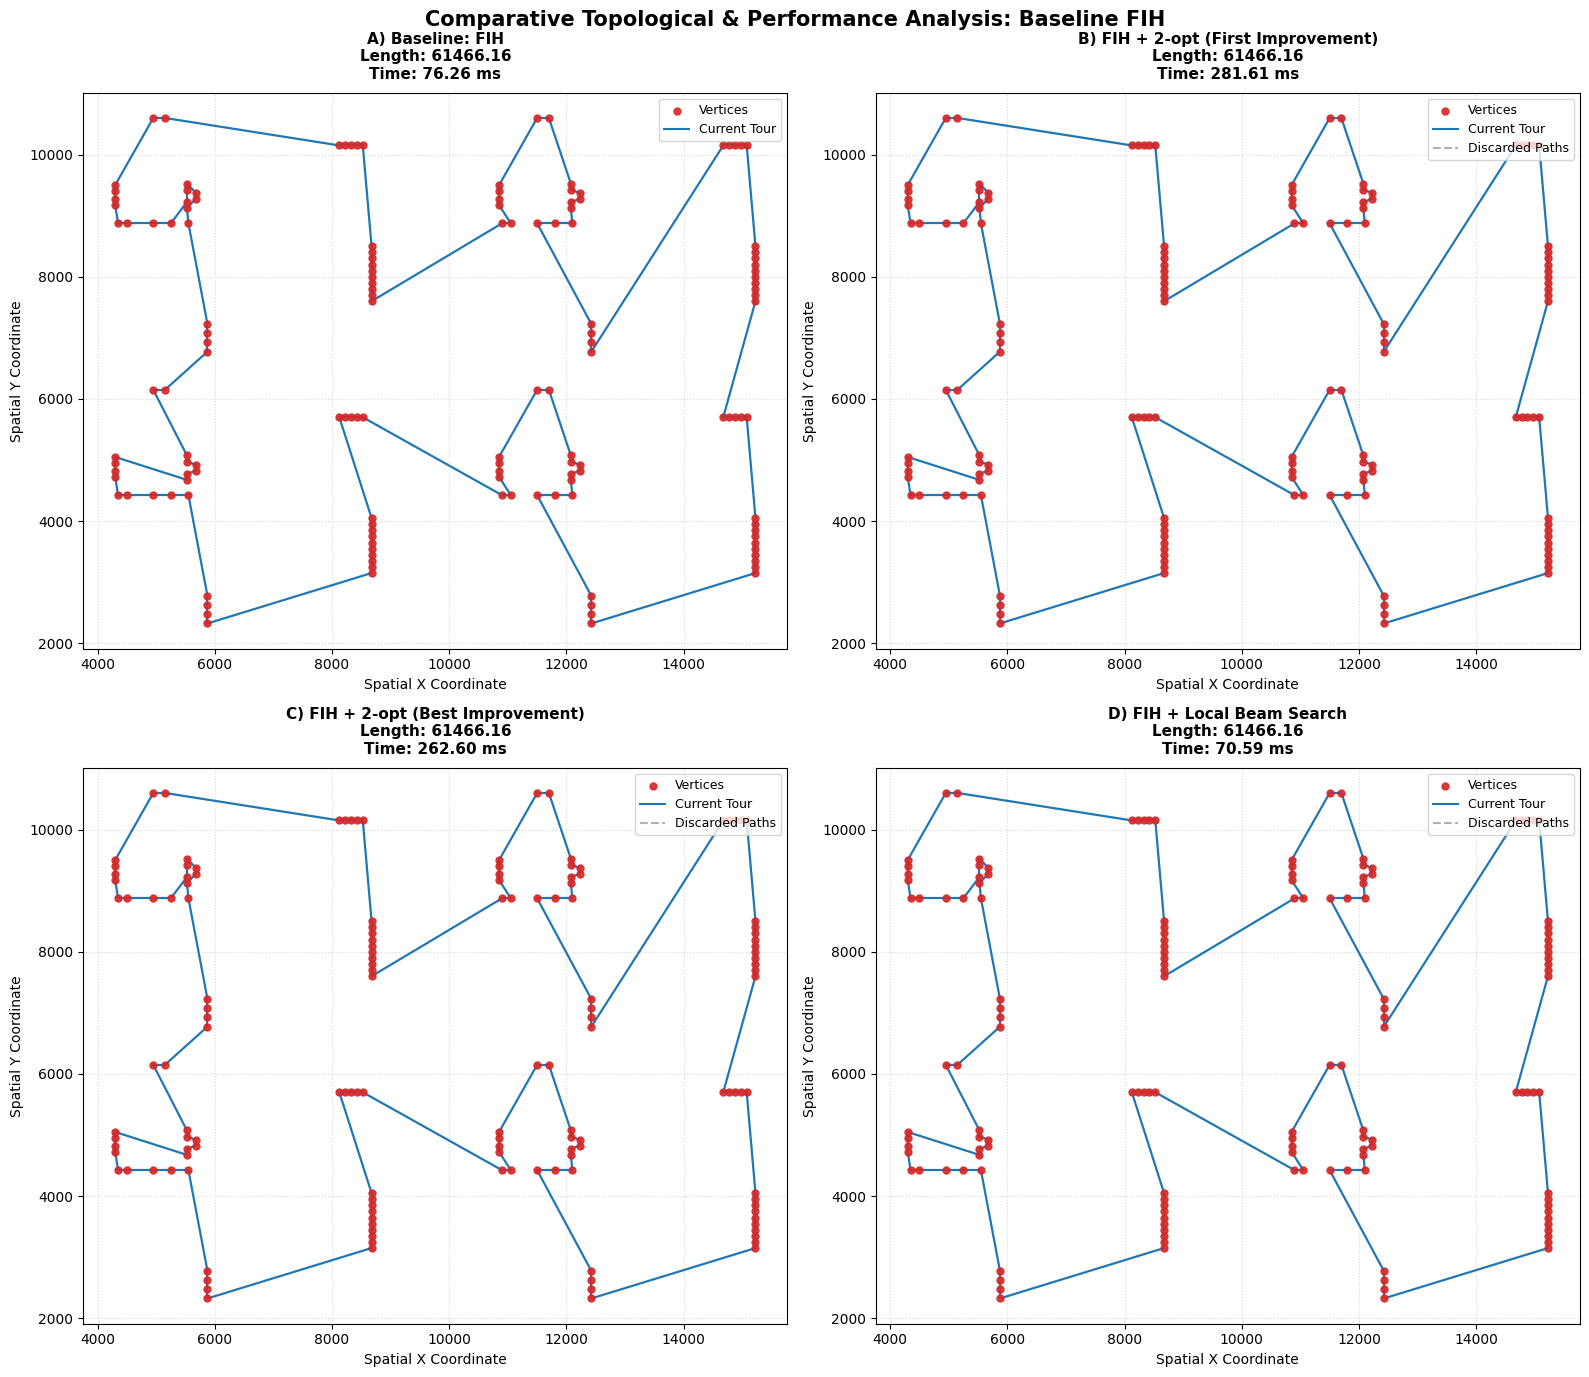

In [25]:
# Compile performance metrics into a structured dictionary for visualization
perf_data = {
    'base':  {'dist': tour_length(tour_far, D),       'time': time_far},
    'first': {'dist': tour_length(tour_far_2opt_first, D), 'time': time_far_2opt_first},
    'best':  {'dist': tour_length(tour_far_2opt_best, D),  'time': time_far_2opt_best},
    'beam':  {'dist': tour_length(tour_far_beam_search, D),'time': time_far_beam_search}
}

# Extracting coordinates from the original data list for plotting
coords = [(item[1], item[2]) for item in l]

plot_local_search_comparison_with_metrics(
    coords, 
    tour_far, 
    tour_far_2opt_first, 
    tour_far_2opt_best, 
    tour_far_beam_search,
    metrics_dict=perf_data,   
    algo_name="FIH"          
)